# Predicción de Retornos de Bitcoin con Redes Recurrentes (RNN / LSTM / GRU)

**Nivel:** Maestría en Ciencia de Datos / Machine Learning  
**Autor:** José Julián Espinel  
**Objetivo:** Construir un pipeline robusto de predicción de retornos logarítmicos diarios de BTC-USD empleando redes recurrentes. Se comparan arquitecturas SimpleRNN, LSTM, BiLSTM y GRU con tuning sistemático de hiperparámetros, validación temporal adecuada y análisis exhaustivo de resultados.

**Mejoras respecto al cuaderno original:**
1. **Feature engineering**: incorporación de volatilidad realizada, retornos rezagados y features técnicos.
2. **Split temporal correcto**: Train / Validation / Test (80-10-10) sin data leakage.
3. **Pipeline modular**: funciones reutilizables para construcción, entrenamiento y evaluación.
4. **Tuning sistemático**: búsqueda estructurada de `LOOK_BACK`, unidades, dropout, learning rate.
5. **Múltiples arquitecturas**: SimpleRNN, LSTM unidireccional, BiLSTM, GRU.
6. **Análisis de residuales**: autocorrelación, normalidad, homocedasticidad.
7. **Métricas direccionales**: Directional Accuracy (DA) para evaluar utilidad práctica.
8. **Reconstrucción de precio** a partir de retornos predichos.

---

## Tabla de Contenidos

1. [Configuración y Librerías](#1)
2. [Adquisición de Datos](#2)
3. [Análisis Exploratorio (EDA)](#3)
4. [Feature Engineering](#4)
5. [Preprocesamiento y Ventanas Temporales](#5)
6. [Baseline Naïve](#6)
7. [Definición del Pipeline de Modelado](#7)
8. [Experimento 1 — SimpleRNN](#8)
9. [Experimento 2 — LSTM Unidireccional](#9)
10. [Experimento 3 — BiLSTM (Bidireccional)](#10)
11. [Experimento 4 — GRU](#11)
12. [Experimento 5 — BiLSTM con Tuning Avanzado](#12)
13. [Tabla Comparativa de Resultados](#13)
14. [Análisis de Residuales del Mejor Modelo](#14)
15. [Reconstrucción del Precio de BTC](#15)
16. [Conclusiones](#16)
17. [Guardar Modelo](#17)

---
<a id="1"></a>
# 1. Configuración y Librerías

Importamos todas las dependencias necesarias y fijamos las semillas de reproducibilidad. Se utiliza TensorFlow/Keras para las redes neuronales y scikit-learn para preprocesamiento y métricas.

In [1]:
# ── 1.1 Librerías ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os
from pathlib import Path

# Preprocessing & metrics
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, SimpleRNN, Dense, Bidirectional,
    Dropout, BatchNormalization, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Estadísticas
from scipy import stats

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ── 1.2 Reproducibilidad ─────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.21.0
GPU disponible: []


---
<a id="2"></a>
# 2. Adquisición de Datos

Se descarga la serie histórica de BTC-USD desde Yahoo Finance (2015-01-01 en adelante). Se implementa un mecanismo de fallback a CSV local para reproducibilidad offline.

In [10]:
%pip install --upgrade yfinance

Note: you may need to restart the kernel to use updated packages.


In [11]:
# ── 2.1 Descarga / carga de datos ─────────────────────────────
DATA_CSV_CANDIDATES = [
    Path("data/BTC-USD.csv"), Path("./data/BTC-USD.csv"),
    Path("../data/BTC-USD.csv"), Path("BTC-USD.csv"),
]

def try_load_csv():
    for p in DATA_CSV_CANDIDATES:
        if p.exists():
            df = pd.read_csv(p, parse_dates=["Date"]).set_index("Date").sort_index()
            print(f"✅ CSV cargado desde: {p.resolve()}")
            return df
    return None

df_btc = None
try:
    import yfinance as yf
    df_btc = yf.download("BTC-USD", start="2015-01-01", interval="1d",
                         auto_adjust=False, progress=False)
    if df_btc is None or len(df_btc) == 0:
        raise RuntimeError("Descarga vacía")
    df_btc = df_btc.reset_index().set_index("Date").sort_index()
    print(f"✅ Descargado BTC-USD via yfinance — {len(df_btc)} filas")
    # Cache
    try:
        Path("data").mkdir(exist_ok=True)
        df_btc.reset_index().to_csv("data/BTC-USD.csv", index=False)
    except: pass
except Exception as e:
    print(f"⚠️ yfinance falló: {e}")
    df_btc = try_load_csv()

if df_btc is None:
    raise FileNotFoundError("No se pudo obtener BTC-USD.")

close = df_btc[["Close"]].dropna().astype(float)
print(f"Rango: {close.index.min().date()} → {close.index.max().date()} ({len(close)} obs.)")
close.head()

✅ Descargado BTC-USD via yfinance — 4116 filas
Rango: 2015-01-01 → 2026-04-08 (4116 obs.)


Price,Close
Ticker,BTC-USD
Date,
2015-01-01,314.248993
2015-01-02,315.032013
2015-01-03,281.082001
2015-01-04,264.195007
2015-01-05,274.473999


---
<a id="3"></a>
# 3. Análisis Exploratorio de Datos (EDA)

Antes de modelar, es fundamental entender la distribución, estacionariedad y propiedades estadísticas de la serie. Los retornos logarítmicos $r_t = \ln(P_t / P_{t-1})$ son preferidos sobre retornos simples porque son aditivos en el tiempo y tienden a una distribución más simétrica.

In [12]:
# ── 3.1 Retornos logarítmicos ──────────────────────────────────
close["log_returns"] = np.log(close["Close"]).diff()
close.dropna(inplace=True)

print(f"Observaciones: {len(close)}")
print(f"Nulos: {close.isna().sum().sum()}")
close.describe()

Observaciones: 4115
Nulos: 0


Price,Close,log_returns
Ticker,BTC-USD,
count,4115.000000,4115.000000
mean,28704.576206,0.001319
std,32281.548397,0.035356
min,178.102997,-0.464730
25%,3854.571655,-0.012423
50%,11815.986328,0.001156
75%,45589.333984,0.015851
max,124752.531250,0.225119


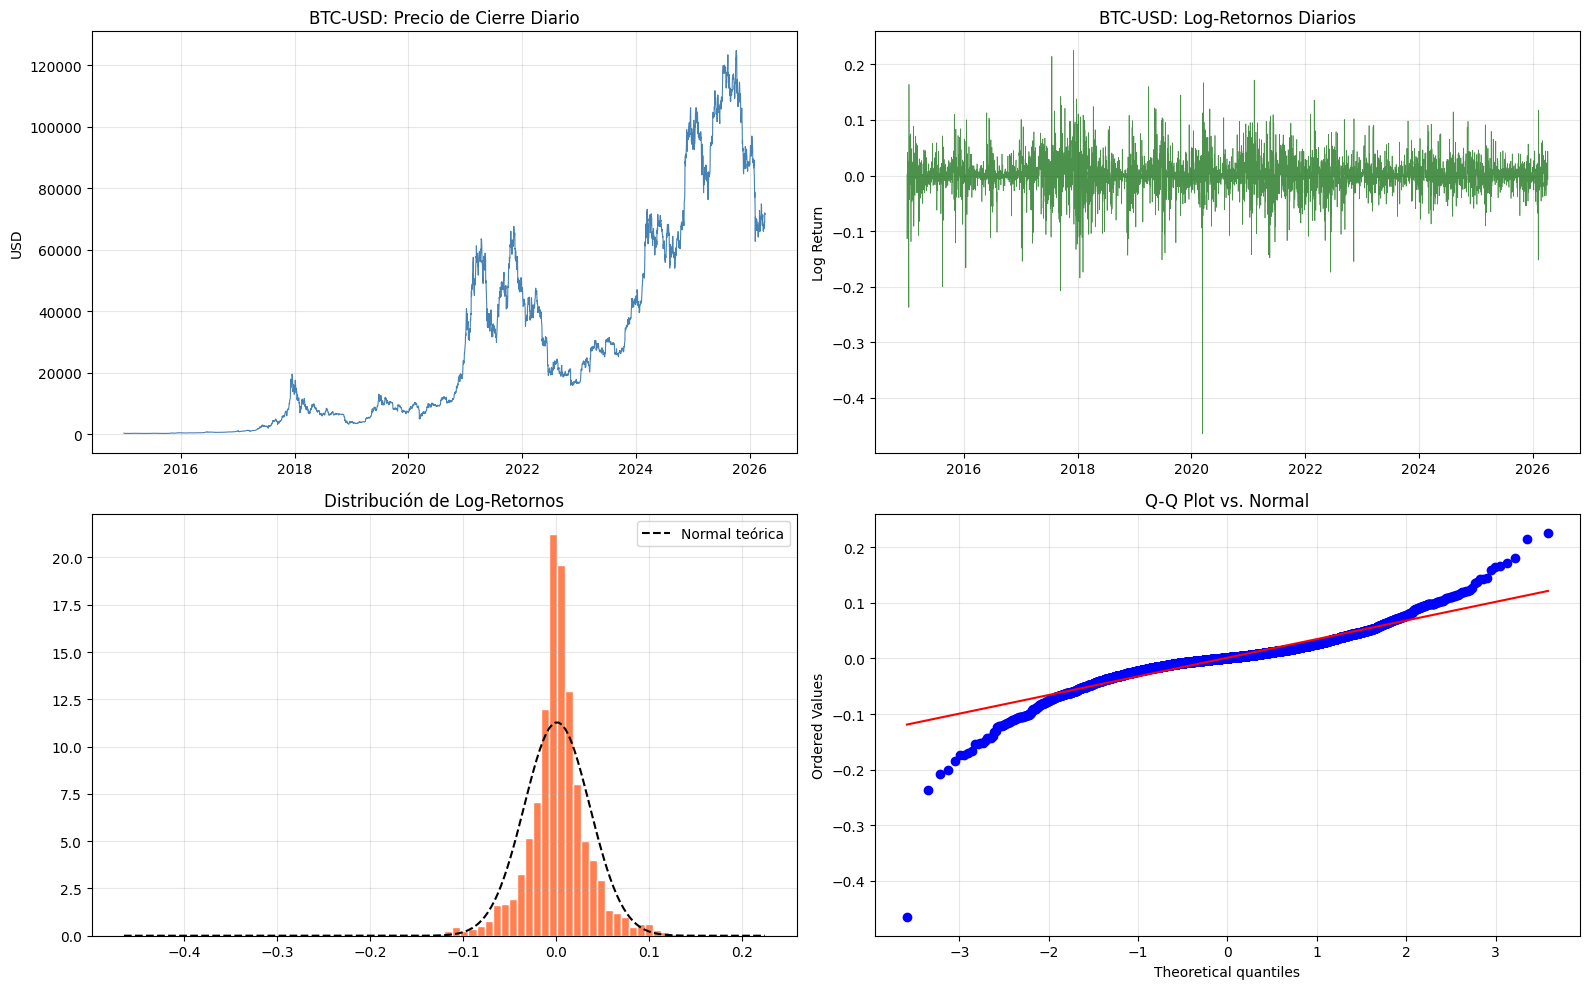

In [47]:
# ── 3.2 Visualización: Precio, Retornos y Distribución ────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Precio
axes[0, 0].plot(close.index, close["Close"], color="steelblue", lw=0.8)
axes[0, 0].set_title("BTC-USD: Precio de Cierre Diario")
axes[0, 0].set_ylabel("USD"); axes[0, 0].grid(True, alpha=0.3)

# Retornos
axes[0, 1].plot(close.index, close["log_returns"], color="darkgreen", lw=0.5, alpha=0.7)
axes[0, 1].set_title("BTC-USD: Log-Retornos Diarios")
axes[0, 1].set_ylabel("Log Return"); axes[0, 1].grid(True, alpha=0.3)

# Distribución
axes[1, 0].hist(close["log_returns"], bins=80, color="coral", edgecolor="white", density=True)
x_range = np.linspace(close["log_returns"].min(), close["log_returns"].max(), 200)
axes[1, 0].plot(x_range, stats.norm.pdf(x_range, close["log_returns"].mean(),
                close["log_returns"].std()), 'k--', lw=1.5, label="Normal teórica")
axes[1, 0].set_title("Distribución de Log-Retornos"); axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# QQ-Plot
stats.probplot(close["log_returns"].values, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot vs. Normal")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

### 3.3 Estadísticos Descriptivos

Evaluamos curtosis, asimetría y el test de Jarque-Bera para confirmar la no-normalidad típica de retornos financieros (colas pesadas / *fat tails*).

In [14]:
# ── 3.3 Tests estadísticos ─────────────────────────────────────
ret = close["log_returns"].values
print(f"Media:     {ret.mean():.6f}")
print(f"Std:       {ret.std():.6f}")
print(f"Skewness:  {stats.skew(ret):.4f}")
print(f"Kurtosis:  {stats.kurtosis(ret):.4f}  (exceso, Normal=0)")
jb_stat, jb_p = stats.jarque_bera(ret)
print(f"Jarque-Bera: stat={jb_stat:.2f}, p-value={jb_p:.2e}")
print("→ Los retornos NO son normales (colas pesadas), lo cual es esperable en cripto.")

Media:     0.001319
Std:       0.035352
Skewness:  -0.7352
Kurtosis:  11.9285  (exceso, Normal=0)
Jarque-Bera: stat=24767.46, p-value=0.00e+00
→ Los retornos NO son normales (colas pesadas), lo cual es esperable en cripto.


---
<a id="4"></a>
# 4. Feature Engineering

Para mejorar la capacidad predictiva, enriquecemos la serie univariada con features derivados:

| Feature | Descripción | Justificación |
|---------|-------------|---------------|
| `log_returns` | Retorno logarítmico diario | Variable objetivo |
| `vol_5d` | Volatilidad realizada (5 días) | Captura clustering de volatilidad (efecto ARCH) |
| `vol_21d` | Volatilidad realizada (21 días) | Volatilidad de mediano plazo |
| `ret_lag1..3` | Retornos rezagados 1-3 días | Autocorrelación de corto plazo |
| `range_hl` | Rango High-Low normalizado | Proxy de volatilidad intradía |

> **Nota:** Todos los features se calculan con información pasada (no hay *look-ahead bias*).

In [15]:
# ── 4.1 Construcción de features ──────────────────────────────
df_feat = close[["log_returns"]].copy()

# Volatilidad realizada (rolling std de retornos)
df_feat["vol_5d"]  = df_feat["log_returns"].rolling(5).std()
df_feat["vol_21d"] = df_feat["log_returns"].rolling(21).std()

# Retornos rezagados
for lag in [1, 2, 3]:
    df_feat[f"ret_lag{lag}"] = df_feat["log_returns"].shift(lag)

# Rango High-Low normalizado (si disponible)
if "High" in df_btc.columns and "Low" in df_btc.columns:
    hl = (df_btc["High"] - df_btc["Low"]) / df_btc["Close"]
    df_feat["range_hl"] = hl.reindex(df_feat.index)

# Eliminar filas con NaN generados por rolling/shift
df_feat.dropna(inplace=True)

print(f"Features finales: {list(df_feat.columns)}")
print(f"Shape: {df_feat.shape}")
df_feat.head(10)

Features finales: [('log_returns', ''), ('vol_5d', ''), ('vol_21d', ''), ('ret_lag1', ''), ('ret_lag2', ''), ('ret_lag3', ''), ('range_hl', '')]
Shape: (4095, 7)


Price,log_returns,vol_5d,vol_21d,ret_lag1,ret_lag2,ret_lag3,range_hl
Ticker,,,,,,,
Date,,,,,,,
2015-01-22,0.028283,0.033599,0.085659,0.071146,-0.016641,0.021271,0.045350
2015-01-23,-0.002260,0.033629,0.085619,0.028283,0.071146,-0.016641,0.041434
2015-01-24,0.062293,0.038551,0.083989,-0.002260,0.028283,0.071146,0.073384
2015-01-25,0.023412,0.030028,0.083207,0.062293,-0.002260,0.028283,0.044080
2015-01-26,0.074979,0.031159,0.084472,0.023412,0.062293,-0.002260,0.202232
2015-01-27,-0.037244,0.046113,0.084269,0.074979,0.023412,0.062293,0.094229
2015-01-28,-0.119001,0.079992,0.087524,-0.037244,0.074979,0.023412,0.168818
2015-01-29,-0.001720,0.072477,0.087321,-0.119001,-0.037244,0.074979,0.077058


### 4.2 Matriz de Correlación

Verificamos las relaciones lineales entre features para detectar multicolinealidad excesiva.

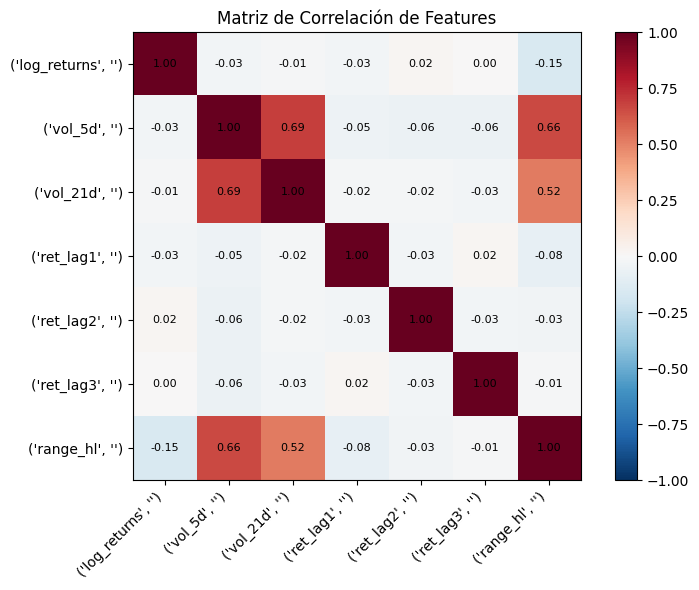

In [16]:
# ── 4.2 Correlaciones ─────────────────────────────────────────
corr = df_feat.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax); plt.title("Matriz de Correlación de Features"); plt.tight_layout(); plt.show()

---
<a id="5"></a>
# 5. Preprocesamiento y Ventanas Temporales

### 5.1 Split Temporal: Train / Validation / Test

Implementamos un split temporal:

- **Train**: 80% de los datos (para entrenar pesos).
- **Validation**: 10% siguiente (para early stopping y selección de modelo).
- **Test**: 10% final (evaluación final, **nunca** usado durante entrenamiento).

### 5.2 Escalamiento

Usamos `RobustScaler` (basado en mediana e IQR) en lugar de `MinMaxScaler`, ya que es más robusto a los outliers típicos de retornos de criptomonedas. El scaler se ajusta **exclusivamente** sobre el conjunto de entrenamiento.

In [17]:
# ── 5.1 Preparar arrays ───────────────────────────────────────
TARGET_COL = "log_returns"
feature_cols = [c for c in df_feat.columns]  # target incluido como primer feature
data_array = df_feat[feature_cols].values  # shape (T, n_features)
n_features = data_array.shape[1]

# ── 5.2 Split temporal 80-10-10 ──────────────────────────────
n = len(data_array)
idx_train_end = int(n * 0.80)
idx_val_end   = int(n * 0.90)

train_raw = data_array[:idx_train_end]
val_raw   = data_array[idx_train_end:idx_val_end]
test_raw  = data_array[idx_val_end:]

print(f"Train: {train_raw.shape[0]} | Val: {val_raw.shape[0]} | Test: {test_raw.shape[0]}")

# ── 5.3 Escalamiento (fit solo en train) ─────────────────────
scaler = RobustScaler()
train_scaled = scaler.fit_transform(train_raw)
val_scaled   = scaler.transform(val_raw)
test_scaled  = scaler.transform(test_raw)

# Guardar scaler params del target (columna 0) para inverse transform
target_idx = 0  # log_returns es la primera columna
target_center = scaler.center_[target_idx]
target_scale  = scaler.scale_[target_idx]

def inverse_target(y_scaled):
    """Deshace el RobustScaler solo para la columna target."""
    return y_scaled * target_scale + target_center

Train: 3276 | Val: 409 | Test: 410


In [18]:
# ── 5.4 Función de ventanas temporales ────────────────────────
def make_windows(series: np.ndarray, look_back: int):
    """
    Genera ventanas supervisadas para series multivariadas.
    
    Args:
        series: array (T, n_features) ya escalado
        look_back: número de pasos hacia atrás
    
    Returns:
        X: (N, look_back, n_features)
        y: (N, 1) — solo la columna target
    """
    X, y = [], []
    for i in range(look_back, len(series)):
        X.append(series[i - look_back : i])      # (look_back, n_features)
        y.append(series[i, target_idx])           # escalar
    return np.array(X), np.array(y).reshape(-1, 1)

# Configuración por defecto
LOOK_BACK = 30

X_train, y_train = make_windows(train_scaled, LOOK_BACK)
X_val,   y_val   = make_windows(val_scaled,   LOOK_BACK)
X_test,  y_test  = make_windows(test_scaled,  LOOK_BACK)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

X_train: (3246, 30, 7)  y_train: (3246, 1)
X_val:   (379, 30, 7)    y_val:   (379, 1)
X_test:  (380, 30, 7)   y_test:  (380, 1)


---
<a id="6"></a>
# 6. Baseline Naïve

El **baseline naïve** para retornos consiste en predecir $\hat{r}_{t+1} = r_t$ (el retorno de mañana es igual al de hoy). Cualquier modelo que no supere este baseline no aporta valor predictivo.

In [19]:
# ── 6.1 Naïve forecast ────────────────────────────────────────
def compute_metrics(y_true, y_pred, label="Model"):
    """Calcula RMSE, MAE, R², y Directional Accuracy."""
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_val  = mean_absolute_error(y_true, y_pred)
    r2_val   = r2_score(y_true, y_pred)
    # Directional accuracy: ¿acertamos el signo del retorno?
    da = np.mean(np.sign(y_true.flatten()) == np.sign(y_pred.flatten())) * 100
    print(f"{label:30s} | RMSE: {rmse_val:.6f} | MAE: {mae_val:.6f} | R²: {r2_val:.4f} | DA: {da:.1f}%")
    return {"label": label, "rmse": rmse_val, "mae": mae_val, "r2": r2_val, "da": da}

# Baseline: predecir el último retorno de la ventana
baseline_pred_scaled = X_test[:, -1, target_idx].reshape(-1, 1)

y_test_real     = inverse_target(y_test)
baseline_real   = inverse_target(baseline_pred_scaled)

results = []
results.append(compute_metrics(y_test_real, baseline_real, "Naïve (tomorrow=today)"))

Naïve (tomorrow=today)         | RMSE: 0.033916 | MAE: 0.023718 | R²: -1.1630 | DA: 50.3%


---
<a id="7"></a>
# 7. Definición del Pipeline de Modelado

Creamos funciones modulares para evitar repetir código en cada experimento. Esto incluye:

- `build_model()`: Fábrica de modelos parametrizable por arquitectura.
- `train_and_evaluate()`: Entrenamiento con callbacks y evaluación completa.
- `plot_training()`: Visualización de curvas de aprendizaje.
- `plot_predictions()`: Comparación predicción vs real.

In [20]:
# ── 7.1 Fábrica de modelos ─────────────────────────────────────
def build_model(arch="bilstm", units=64, dropout=0.1, lr=1e-3,
                look_back=LOOK_BACK, n_feat=n_features, n_layers=2):
    """
    Construye un modelo recurrente.
    
    Args:
        arch: 'rnn', 'lstm', 'bilstm', 'gru'
        units: unidades por capa recurrente
        dropout: tasa de dropout
        lr: learning rate
        look_back: ventana temporal
        n_feat: número de features de entrada
        n_layers: número de capas recurrentes
    """
    layer_map = {
        "rnn":    lambda u, rs: SimpleRNN(u, return_sequences=rs),
        "lstm":   lambda u, rs: LSTM(u, return_sequences=rs),
        "bilstm": lambda u, rs: Bidirectional(LSTM(u, return_sequences=rs)),
        "gru":    lambda u, rs: GRU(u, return_sequences=rs),
    }
    
    rnn_layer = layer_map[arch]
    model = Sequential()
    model.add(Input(shape=(look_back, n_feat)))
    
    for i in range(n_layers):
        rs = (i < n_layers - 1)  # return_sequences=True salvo en la última capa recurrente
        model.add(rnn_layer(units, rs))
        if dropout > 0:
            model.add(Dropout(dropout))
    
    model.add(BatchNormalization())
    model.add(Dense(units // 2, activation="relu"))
    model.add(Dense(1))  # Salida lineal para regresión
    
    model.compile(optimizer=Adam(learning_rate=lr), loss="huber")  # Huber: robusta a outliers
    return model

In [21]:
# ── 7.2 Entrenamiento y evaluación ─────────────────────────────
def train_and_evaluate(model, X_tr, y_tr, X_v, y_v, X_te, y_te,
                       epochs=150, batch_size=64, label="Model", patience=15):
    """Entrena el modelo y retorna métricas + historia."""
    
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=patience,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=patience // 3, min_lr=1e-6, verbose=0),
    ]
    
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    
    # Predicción
    pred_scaled = model.predict(X_te, verbose=0)
    pred_real   = inverse_target(pred_scaled)
    y_te_real   = inverse_target(y_te)
    
    metrics = compute_metrics(y_te_real, pred_real, label)
    
    return history, pred_real, y_te_real, metrics

In [22]:
# ── 7.3 Funciones de visualización ─────────────────────────────
def plot_training(history, title="Curva de Aprendizaje"):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history.history["loss"], label="Train Loss", lw=1.2)
    ax.plot(history.history["val_loss"], label="Val Loss", lw=1.2)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (Huber)")
    ax.grid(True, alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

def plot_predictions(y_real, y_pred, baseline, label="Model"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    # Serie temporal
    axes[0].plot(y_real, color="black", lw=0.8, label="Real")
    axes[0].plot(y_pred, lw=0.8, label=f"Pred ({label})", alpha=0.8)
    axes[0].plot(baseline, lw=0.6, label="Baseline Naïve", alpha=0.5, color="gray")
    axes[0].set_title(f"Predicción vs Real — {label}")
    axes[0].set_xlabel("Días (test)"); axes[0].set_ylabel("Log Return")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    # Scatter
    axes[1].scatter(y_real, y_pred, s=10, alpha=0.4)
    lim = max(abs(y_real).max(), abs(y_pred).max()) * 1.1
    axes[1].plot([-lim, lim], [-lim, lim], "r--", lw=1)
    axes[1].set_xlim(-lim, lim); axes[1].set_ylim(-lim, lim)
    axes[1].set_xlabel("Real"); axes[1].set_ylabel("Predicho")
    axes[1].set_title("Scatter: Real vs Predicho"); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

---
<a id="8"></a>
# 8. Experimento 1 — SimpleRNN

La red recurrente simple (Elman RNN) es el modelo base. Su principal limitación es el *vanishing gradient*, que dificulta capturar dependencias de largo plazo. Sirve como punto de referencia para justificar arquitecturas más complejas.

| Hiperparámetro | Valor |
|---|---|
| Arquitectura | SimpleRNN (2 capas) |
| Unidades | 64 |
| Dropout | 0.1 |
| Learning Rate | 0.001 |
| Loss | Huber |
| LOOK_BACK | 30 |

In [23]:
# ── 8.1 Entrenar SimpleRNN ─────────────────────────────────────
model_rnn = build_model(arch="rnn", units=64, dropout=0.1, lr=1e-3)
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 64)         │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 15,105 (59.00 KB)

 Non-trainable params: 128 (512.00 B)

In [24]:
hist_rnn, pred_rnn, y_real, met_rnn = train_and_evaluate(
    model_rnn, X_train, y_train, X_val, y_val, X_test, y_test,
    label="SimpleRNN (64u, LB=30)"
)
results.append(met_rnn)

Epoch 1/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 0.5748 - val_loss: 0.3588 - learning_rate: 0.0010
Epoch 2/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.5189 - val_loss: 0.3698 - learning_rate: 0.0010
Epoch 3/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.5058 - val_loss: 0.3666 - learning_rate: 0.0010
Epoch 4/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.4929 - val_loss: 0.3607 - learning_rate: 0.0010
Epoch 5/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.4793 - val_loss: 0.3706 - learning_rate: 0.0010
Epoch 6/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.4841 - val_loss: 0.3733 - learning_rate: 0.0010
Epoch 7/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.4732 - val_loss: 0.3618 - learning_rate: 5.0000e-04
Epoch 8/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4668 - val_loss: 0.3606 - learning_rate: 5.0000e-04
Epoch 9/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4642 - val_loss: 0.3596 - learning_rate: 5.0000e-

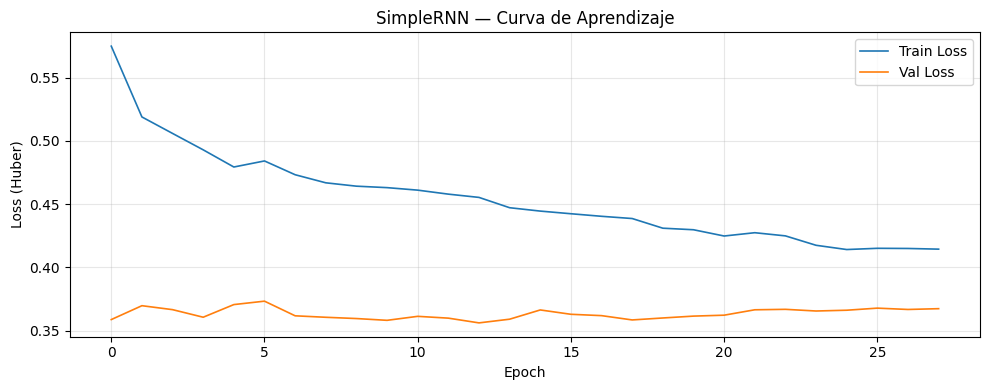

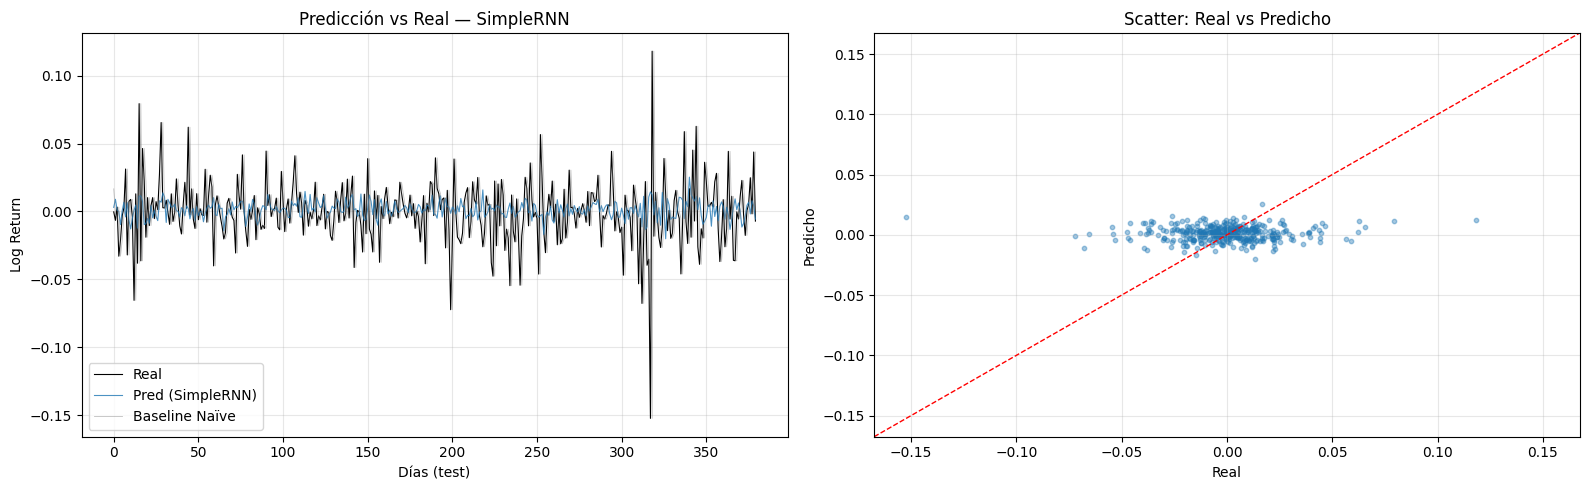

In [25]:
plot_training(hist_rnn, "SimpleRNN — Curva de Aprendizaje")
plot_predictions(y_real, pred_rnn, baseline_real, "SimpleRNN")

---
<a id="9"></a>
# 9. Experimento 2 — LSTM Unidireccional

Las celdas LSTM (*Long Short-Term Memory*) incorporan compuertas de olvido, entrada y salida que mitigan el problema del *vanishing gradient*. Son el estándar de facto para series temporales con dependencias de mediano plazo.

| Hiperparámetro | Valor |
|---|---|
| Arquitectura | LSTM (2 capas) |
| Unidades | 64 |
| Dropout | 0.15 |
| Learning Rate | 0.001 |
| Loss | Huber |

In [26]:
# ── 9.1 Entrenar LSTM ──────────────────────────────────────────
model_lstm = build_model(arch="lstm", units=64, dropout=0.15, lr=1e-3)
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,825 (210.25 KB)

 Trainable params: 53,697 (209.75 KB)

 Non-trainable params: 128 (512.00 B)

In [27]:
hist_lstm, pred_lstm, _, met_lstm = train_and_evaluate(
    model_lstm, X_train, y_train, X_val, y_val, X_test, y_test,
    label="LSTM (64u, LB=30)"
)
results.append(met_lstm)

Epoch 1/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - loss: 0.5704 - val_loss: 0.3497 - learning_rate: 0.0010
Epoch 2/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.5350 - val_loss: 0.3478 - learning_rate: 0.0010
Epoch 3/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.5212 - val_loss: 0.3492 - learning_rate: 0.0010
Epoch 4/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.5156 - val_loss: 0.3484 - learning_rate: 0.0010
Epoch 5/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.5083 - val_loss: 0.3499 - learning_rate: 0.0010
Epoch 6/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.5034 - val_loss: 0.3486 - learning_rate: 0.0010
Epoch 7/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.5001 - val_loss: 0.3500 - learning_rate: 0.0010
Epoch 8/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.5006 - val_loss: 0.3490 - learning_rate: 5.0000e-04
Epoch 9/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.4916 - val_loss: 0.3479 - learning_rate: 5.0000e-04
E

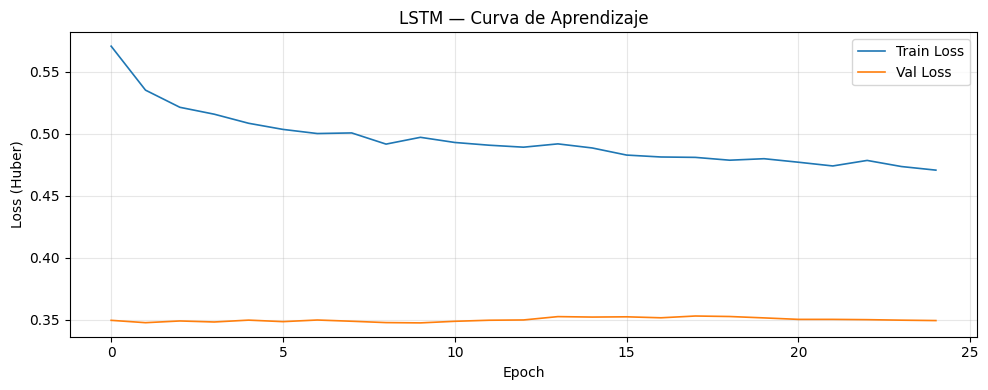

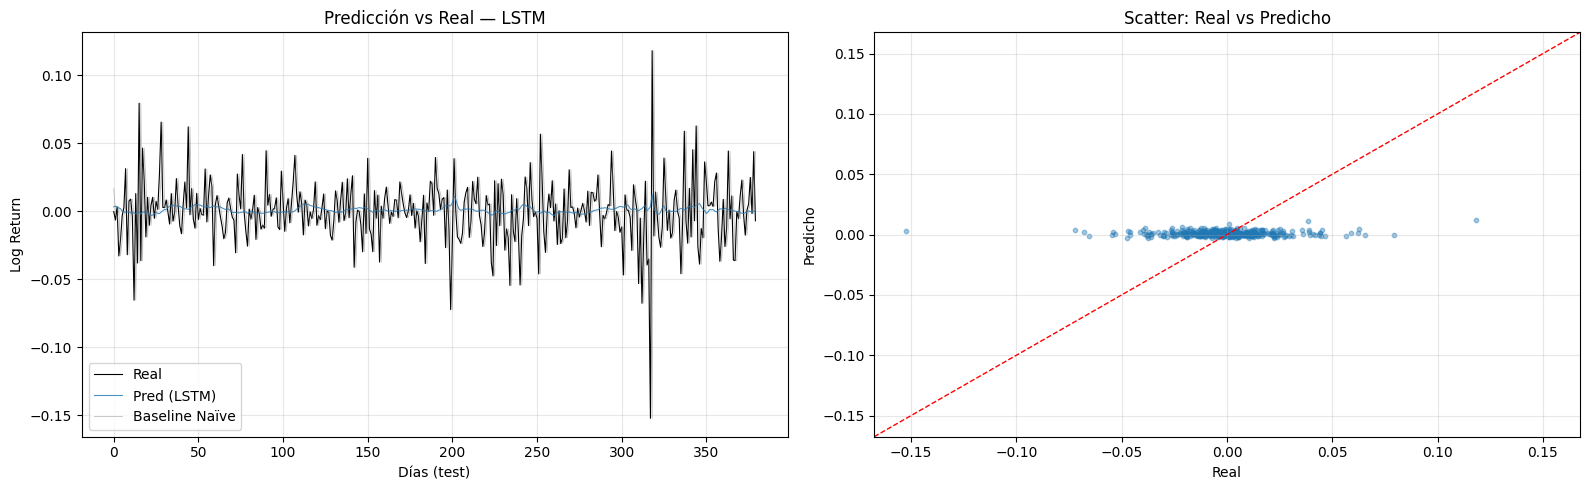

In [28]:
plot_training(hist_lstm, "LSTM — Curva de Aprendizaje")
plot_predictions(y_real, pred_lstm, baseline_real, "LSTM")

---
<a id="10"></a>
# 10. Experimento 3 — BiLSTM (Bidireccional)

La LSTM bidireccional procesa la secuencia en ambas direcciones temporales. Aunque en predicción pura el futuro no está disponible, la bidireccionalidad puede capturar patrones contextuales más ricos dentro de la ventana de entrada.

| Hiperparámetro | Valor |
|---|---|
| Arquitectura | BiLSTM (2 capas) |
| Unidades | 64 |
| Dropout | 0.15 |
| Learning Rate | 0.001 |

In [29]:
# ── 10.1 Entrenar BiLSTM ───────────────────────────────────────
model_bilstm = build_model(arch="bilstm", units=64, dropout=0.15, lr=1e-3)
model_bilstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,353 (548.25 KB)

 Trainable params: 140,097 (547.25 KB)

 Non-trainable params: 256 (1.00 KB)

In [30]:
hist_bilstm, pred_bilstm, _, met_bilstm = train_and_evaluate(
    model_bilstm, X_train, y_train, X_val, y_val, X_test, y_test,
    label="BiLSTM (64u, LB=30)"
)
results.append(met_bilstm)

Epoch 1/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 41s 132ms/step - loss: 0.5563 - val_loss: 0.3496 - learning_rate: 0.0010
Epoch 2/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.5318 - val_loss: 0.3505 - learning_rate: 0.0010
Epoch 3/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.5113 - val_loss: 0.3502 - learning_rate: 0.0010
Epoch 4/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.5076 - val_loss: 0.3517 - learning_rate: 0.0010
Epoch 5/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.4981 - val_loss: 0.3516 - learning_rate: 0.0010
Epoch 6/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.4958 - val_loss: 0.3505 - learning_rate: 0.0010
Epoch 7/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.4861 - val_loss: 0.3502 - learning_rate: 5.0000e-04
Epoch 8/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 0.4813 - val_loss: 0.3479 - learning_rate: 5.0000e-04
Epoch 9/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.4808 - val_loss: 0.3499 - learning_rate: 5.0000e

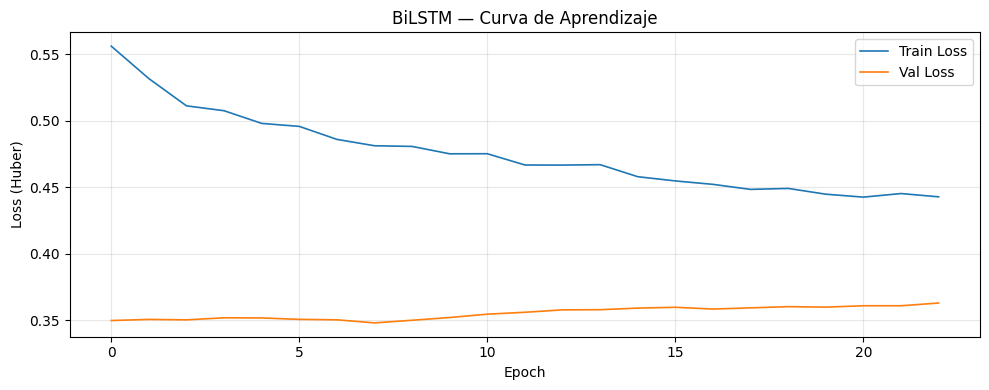

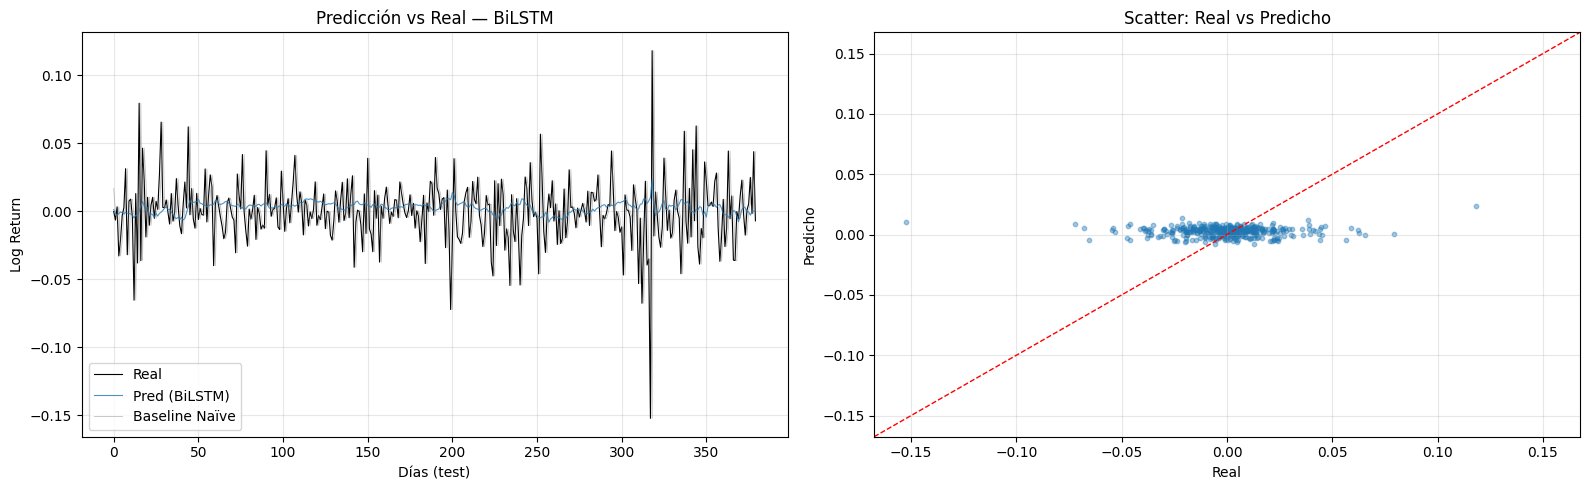

In [31]:
plot_training(hist_bilstm, "BiLSTM — Curva de Aprendizaje")
plot_predictions(y_real, pred_bilstm, baseline_real, "BiLSTM")

---
<a id="11"></a>
# 11. Experimento 4 — GRU

Las *Gated Recurrent Units* simplifican la LSTM al combinar las compuertas de olvido y entrada en una sola compuerta de actualización. Tienen menos parámetros y a menudo rinden de forma comparable, con entrenamiento más rápido.

| Hiperparámetro | Valor |
|---|---|
| Arquitectura | GRU (2 capas) |
| Unidades | 64 |
| Dropout | 0.15 |
| Learning Rate | 0.001 |

In [32]:
# ── 11.1 Entrenar GRU ──────────────────────────────────────────
model_gru = build_model(arch="gru", units=64, dropout=0.15, lr=1e-3)
model_gru.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,345 (161.50 KB)

 Trainable params: 41,217 (161.00 KB)

 Non-trainable params: 128 (512.00 B)

In [33]:
hist_gru, pred_gru, _, met_gru = train_and_evaluate(
    model_gru, X_train, y_train, X_val, y_val, X_test, y_test,
    label="GRU (64u, LB=30)"
)
results.append(met_gru)

Epoch 1/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - loss: 0.5634 - val_loss: 0.3499 - learning_rate: 0.0010
Epoch 2/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.5224 - val_loss: 0.3472 - learning_rate: 0.0010
Epoch 3/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.5188 - val_loss: 0.3480 - learning_rate: 0.0010
Epoch 4/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.5060 - val_loss: 0.3476 - learning_rate: 0.0010
Epoch 5/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.5056 - val_loss: 0.3441 - learning_rate: 0.0010
Epoch 6/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.5002 - val_loss: 0.3450 - learning_rate: 0.0010
Epoch 7/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.4959 - val_loss: 0.3457 - learning_rate: 0.0010
Epoch 8/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.4946 - val_loss: 0.3475 - learning_rate: 0.0010
Epoch 9/150
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.4935 - val_loss: 0.3473 - learning_rate: 0.0010
Epoch 10/

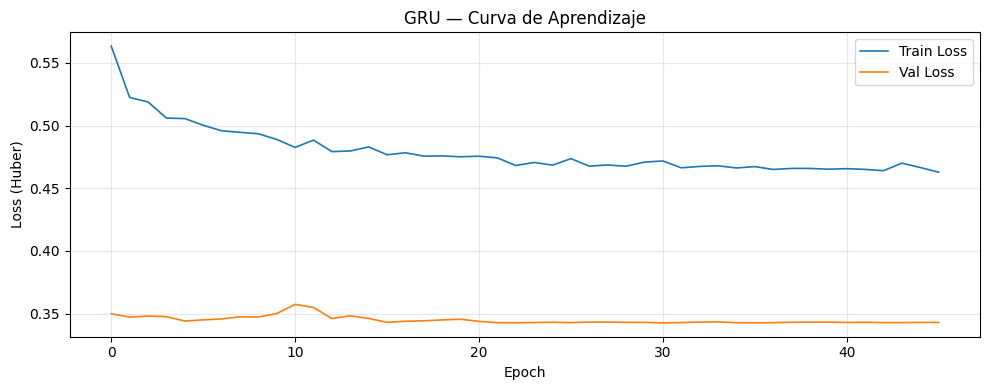

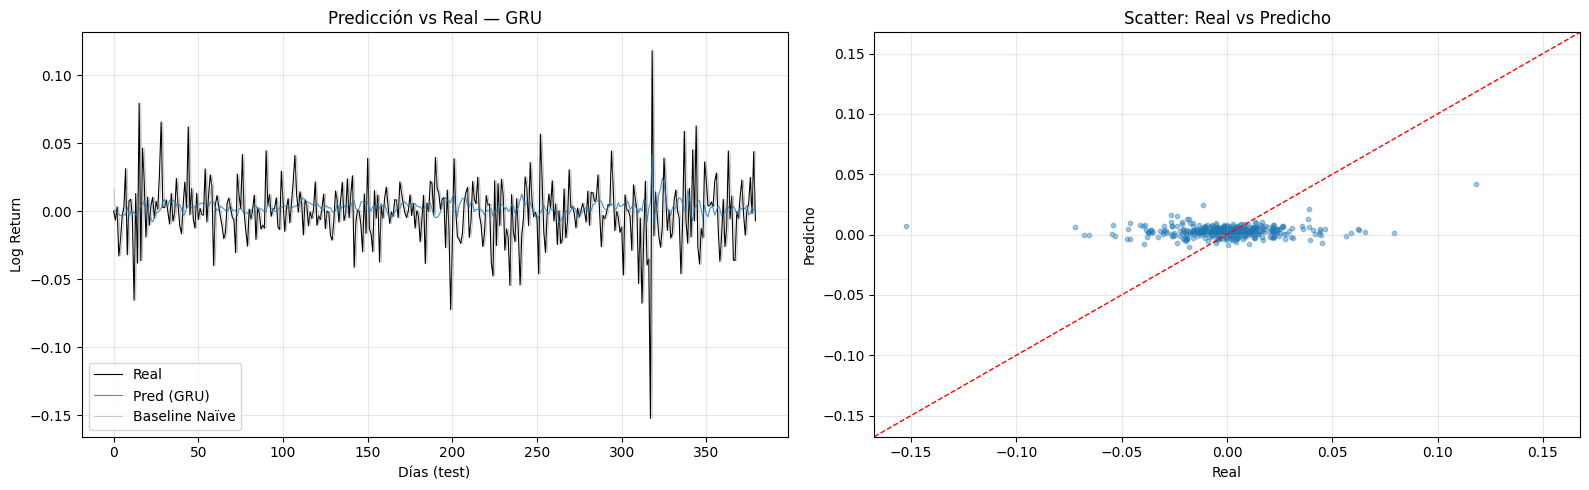

In [34]:
plot_training(hist_gru, "GRU — Curva de Aprendizaje")
plot_predictions(y_real, pred_gru, baseline_real, "GRU")

---
<a id="12"></a>
# 12. Experimento 5 — Tuning Sistemático de BiLSTM

Realizamos una búsqueda grid acotada sobre los hiperparámetros más influyentes del mejor tipo de arquitectura. Esto permite encontrar la configuración óptima de forma metódica.

**Espacio de búsqueda:**
- `LOOK_BACK`: {10, 30, 60}
- `units`: {32, 64, 128}
- `dropout`: {0.05, 0.15, 0.25}
- `learning_rate`: {5e-4, 1e-3}

> Se evalúa cada combinación en validación y se reporta el top-5.

In [35]:
# ── 12.1 Grid Search ───────────────────────────────────────────
from itertools import product as cart_product

look_backs = [10, 30, 60]
units_list = [32, 64, 128]
dropouts   = [0.05, 0.15, 0.25]
lrs        = [5e-4, 1e-3]

tuning_results = []
best_val_loss = float("inf")
best_config = None

total = len(look_backs) * len(units_list) * len(dropouts) * len(lrs)
print(f"Total de configuraciones a evaluar: {total}\n")

for i, (lb, u, d, lr) in enumerate(cart_product(look_backs, units_list, dropouts, lrs)):
    # Reconstruir ventanas para este look_back
    Xtr, ytr = make_windows(train_scaled, lb)
    Xv,  yv  = make_windows(val_scaled,   lb)
    Xte, yte = make_windows(test_scaled,  lb)
    
    model = build_model(arch="bilstm", units=u, dropout=d, lr=lr, look_back=lb)
    
    cb = [EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=0)]
    
    hist = model.fit(Xtr, ytr, validation_data=(Xv, yv),
                     epochs=80, batch_size=64, callbacks=cb, verbose=0)
    
    val_loss = min(hist.history["val_loss"])
    
    config = {"look_back": lb, "units": u, "dropout": d, "lr": lr, "val_loss": val_loss}
    tuning_results.append(config)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_config = config
    
    if (i + 1) % 9 == 0 or (i + 1) == total:
        print(f"  [{i+1}/{total}] Mejor hasta ahora: {best_config}")

print(f"\n✅ Mejor configuración: {best_config}")

Total de configuraciones a evaluar: 54

  [9/54] Mejor hasta ahora: {'look_back': 10, 'units': 32, 'dropout': 0.15, 'lr': 0.001, 'val_loss': 0.3389908969402313}
  [18/54] Mejor hasta ahora: {'look_back': 10, 'units': 32, 'dropout': 0.15, 'lr': 0.001, 'val_loss': 0.3389908969402313}
  [27/54] Mejor hasta ahora: {'look_back': 10, 'units': 32, 'dropout': 0.15, 'lr': 0.001, 'val_loss': 0.3389908969402313}
  [36/54] Mejor hasta ahora: {'look_back': 10, 'units': 32, 'dropout': 0.15, 'lr': 0.001, 'val_loss': 0.3389908969402313}
  [45/54] Mejor hasta ahora: {'look_back': 10, 'units': 32, 'dropout': 0.15, 'lr': 0.001, 'val_loss': 0.3389908969402313}
  [54/54] Mejor hasta ahora: {'look_back': 60, 'units': 64, 'dropout': 0.15, 'lr': 0.001, 'val_loss': 0.33872190117836}

✅ Mejor configuración: {'look_back': 60, 'units': 64, 'dropout': 0.15, 'lr': 0.001, 'val_loss': 0.33872190117836}


In [36]:
# ── 12.2 Top-5 configuraciones ─────────────────────────────────

df_tuning = pd.DataFrame(tuning_results).sort_values("val_loss")
print("Top-5 configuraciones por Val Loss:\n")
df_tuning.head(10)

Top-5 configuraciones por Val Loss:



,look_back,units,dropout,lr,val_loss
45,60,64,0.15,0.0010,0.338722
3,10,32,0.15,0.0010,0.338991
50,60,128,0.15,0.0005,0.339045
53,60,128,0.25,0.0010,0.339719
44,60,64,0.15,0.0005,0.339730
37,60,32,0.05,0.0010,0.340288
10,10,64,0.25,0.0005,0.340399
48,60,128,0.05,0.0005,0.340828
17,10,128,0.25,0.0010,0.341284
8,10,64,0.15,0.0005,0.341491


In [37]:
# ── 12.3 Entrenar modelo final con mejor config ───────────────
bc = best_config
LB_BEST = bc["look_back"]

Xtr_best, ytr_best = make_windows(train_scaled, LB_BEST)
Xv_best,  yv_best  = make_windows(val_scaled,   LB_BEST)
Xte_best, yte_best = make_windows(test_scaled,  LB_BEST)

model_best = build_model(arch="bilstm", units=bc["units"], dropout=bc["dropout"],
                          lr=bc["lr"], look_back=LB_BEST)

hist_best, pred_best, y_real_best, met_best = train_and_evaluate(
    model_best, Xtr_best, ytr_best, Xv_best, yv_best, Xte_best, yte_best,
    label=f"BiLSTM Tuned (u={bc['units']}, LB={LB_BEST})", epochs=200, patience=20
)
results.append(met_best)

Epoch 1/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 257ms/step - loss: 0.6197 - val_loss: 0.3414 - learning_rate: 0.0010
Epoch 2/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 230ms/step - loss: 0.5605 - val_loss: 0.3431 - learning_rate: 0.0010
Epoch 3/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 242ms/step - loss: 0.5360 - val_loss: 0.3431 - learning_rate: 0.0010
Epoch 4/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 311ms/step - loss: 0.5245 - val_loss: 0.3413 - learning_rate: 0.0010
Epoch 5/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 468ms/step - loss: 0.5126 - val_loss: 0.3419 - learning_rate: 0.0010
Epoch 6/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 39s 411ms/step - loss: 0.5039 - val_loss: 0.3418 - learning_rate: 0.0010
Epoch 7/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 292ms/step - loss: 0.4969 - val_loss: 0.3458 - learning_rate: 0.0010
Epoch 8/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 18s 244ms/step - loss: 0.5001 - val_loss: 0.3497 - learning_rate: 0.0010
Epoch 9/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 224ms/step - loss: 0.4960 - val_loss: 0.3469 - learning_rate:

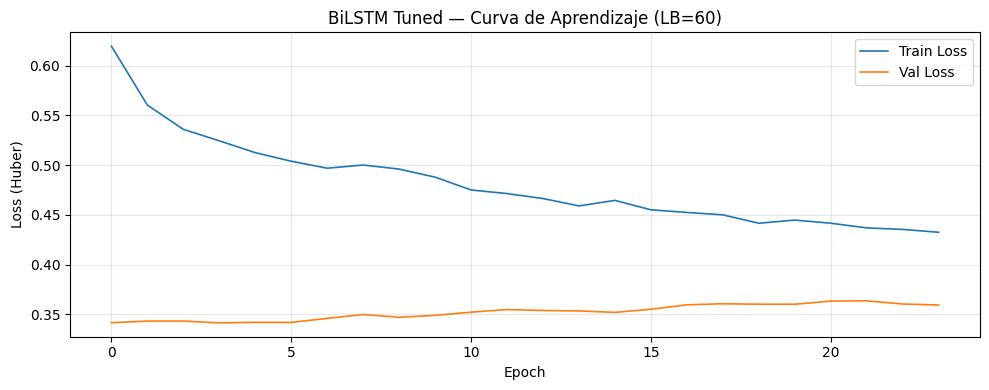

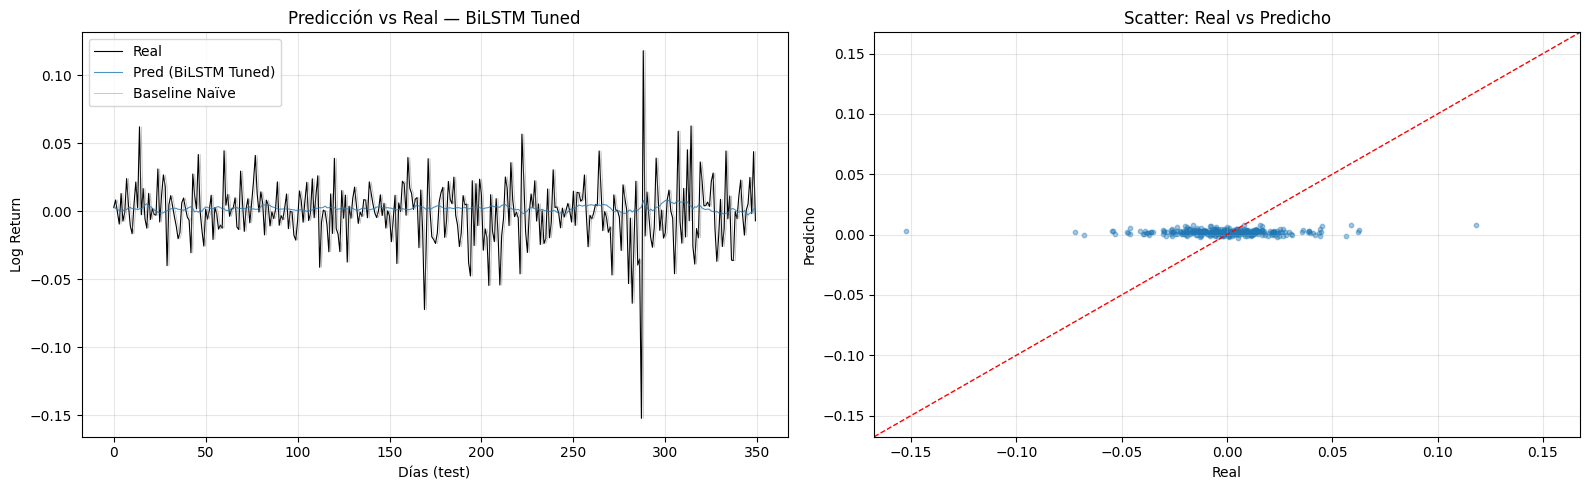

In [38]:
plot_training(hist_best, f"BiLSTM Tuned — Curva de Aprendizaje (LB={LB_BEST})")
# Recalcular baseline para este look_back
baseline_best = inverse_target(Xte_best[:, -1, target_idx].reshape(-1, 1))
plot_predictions(y_real_best, pred_best, baseline_best, "BiLSTM Tuned")

---
<a id="13"></a>
# 13. Tabla Comparativa de Resultados

Consolidamos todas las métricas en una tabla para facilitar la comparación. La métrica **Directional Accuracy (DA)** es especialmente relevante en finanzas: un modelo puede tener RMSE bajo pero ser inútil si no acierta la dirección del movimiento.

In [39]:
# ── 13.1 Tabla de resultados ───────────────────────────────────
df_results = pd.DataFrame(results)
df_results = df_results.sort_values("rmse")

# Formatear
styled = df_results.style.format({
    "rmse": "{:.6f}", "mae": "{:.6f}", "r2": "{:.4f}", "da": "{:.1f}%"
}).background_gradient(subset=["rmse"], cmap="RdYlGn_r"
).background_gradient(subset=["da"], cmap="RdYlGn")

styled

,label,rmse,mae,r2,da
5,"BiLSTM Tuned (u=64, LB=60)",0.022624,0.015795,-0.0164,46.3%
2,"LSTM (64u, LB=30)",0.023118,0.016167,-0.0050,46.1%
4,"GRU (64u, LB=30)",0.023219,0.016300,-0.0138,49.7%
3,"BiLSTM (64u, LB=30)",0.023610,0.016600,-0.0481,49.2%
1,"SimpleRNN (64u, LB=30)",0.023819,0.016777,-0.0668,47.9%
0,Naïve (tomorrow=today),0.033916,0.023718,-1.1630,50.3%


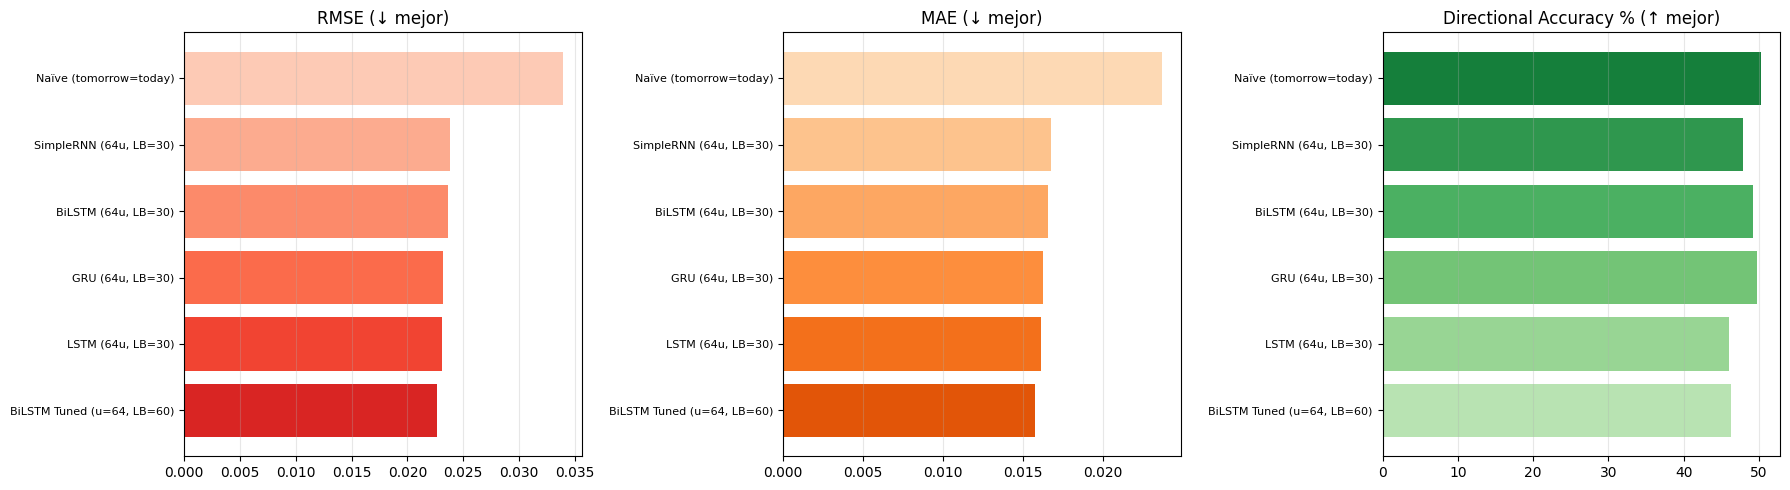

In [40]:
# ── 13.2 Gráfico comparativo ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = df_results["label"].values
x = np.arange(len(labels))

for ax, col, title, cmap in zip(
    axes, ["rmse", "mae", "da"],
    ["RMSE (↓ mejor)", "MAE (↓ mejor)", "Directional Accuracy % (↑ mejor)"],
    ["Reds_r", "Oranges_r", "Greens"]
):
    vals = df_results[col].values
    colors = plt.cm.get_cmap(cmap)(np.linspace(0.3, 0.8, len(vals)))
    ax.barh(x, vals, color=colors)
    ax.set_yticks(x); ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(title); ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout(); plt.show()

---
<a id="14"></a>
# 14. Análisis de Residuales del Mejor Modelo

Un buen modelo debe producir residuales que se comporten como ruido blanco: sin autocorrelación, sin tendencia, y con distribución aproximadamente simétrica. Evaluamos:

1. **Serie temporal de residuales**: ¿hay patrones visibles?
2. **Histograma**: ¿distribución centrada en cero?
3. **Autocorrelación (ACF)**: ¿hay estructura temporal remanente?
4. **Q-Q Plot**: ¿qué tan lejos de la normalidad?

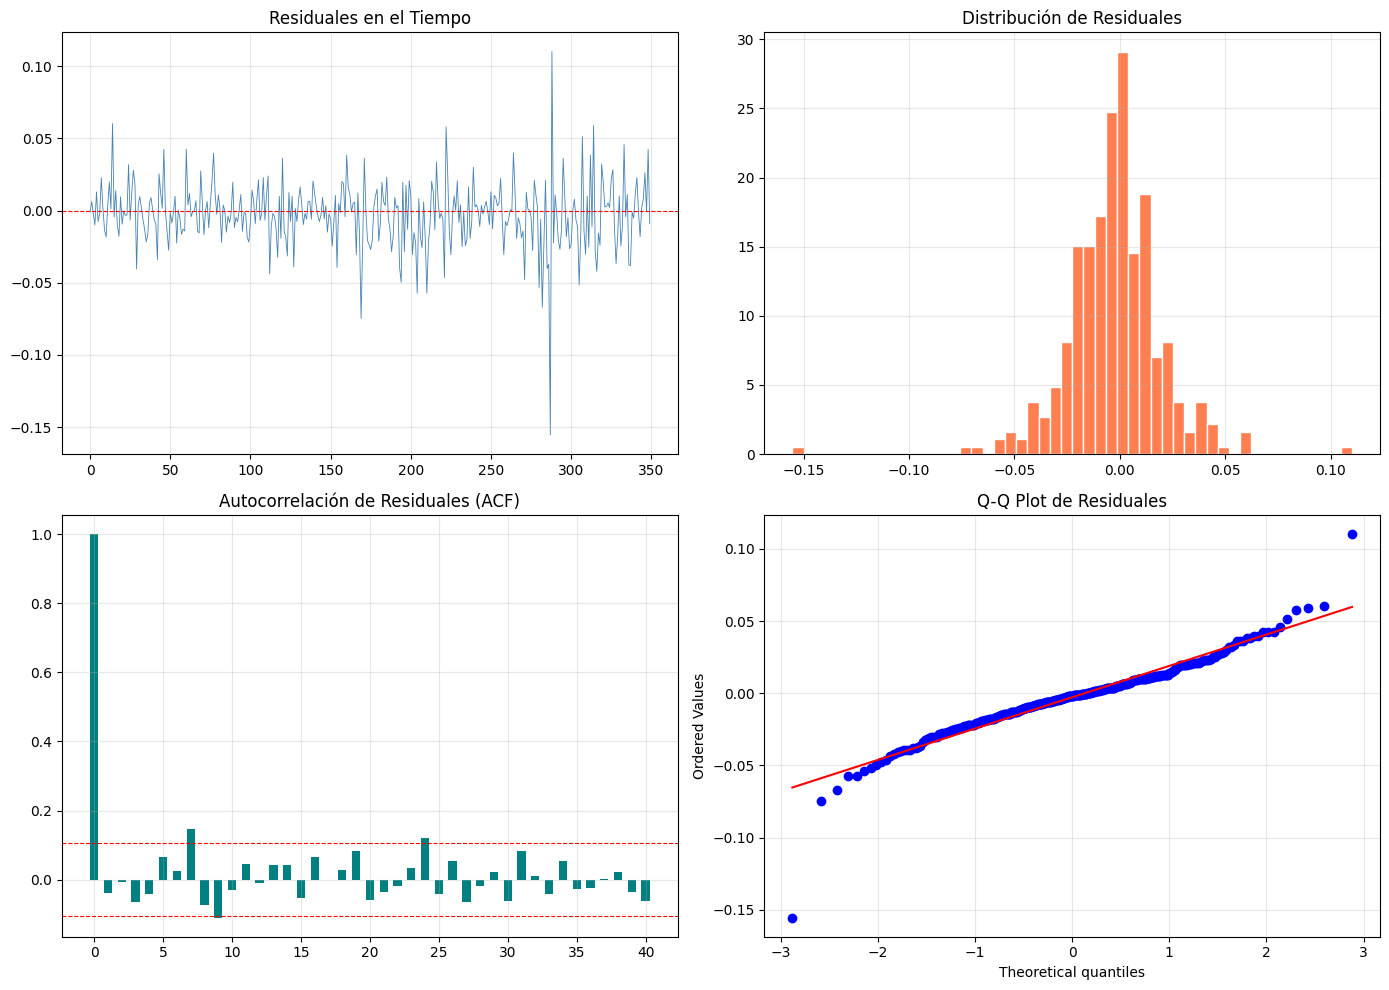


Media residuales: -0.002762
Std residuales:   0.022455
Jarque-Bera residuales: stat=841.12, p=0.0000


In [41]:
# ── 14.1 Residuales ───────────────────────────────────────────
residuals = y_real_best.flatten() - pred_best.flatten()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Serie temporal
axes[0, 0].plot(residuals, lw=0.6, color="steelblue")
axes[0, 0].axhline(0, color="red", ls="--", lw=0.8)
axes[0, 0].set_title("Residuales en el Tiempo"); axes[0, 0].grid(True, alpha=0.3)

# Histograma
axes[0, 1].hist(residuals, bins=50, color="coral", edgecolor="white", density=True)
axes[0, 1].set_title("Distribución de Residuales"); axes[0, 1].grid(True, alpha=0.3)

# ACF manual
max_lag = 40
acf_vals = [np.corrcoef(residuals[:-k], residuals[k:])[0, 1] if k > 0 else 1.0
            for k in range(max_lag + 1)]
axes[1, 0].bar(range(max_lag + 1), acf_vals, color="teal", width=0.6)
conf = 1.96 / np.sqrt(len(residuals))
axes[1, 0].axhline(conf, ls="--", color="red", lw=0.8)
axes[1, 0].axhline(-conf, ls="--", color="red", lw=0.8)
axes[1, 0].set_title("Autocorrelación de Residuales (ACF)"); axes[1, 0].grid(True, alpha=0.3)

# QQ
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot de Residuales"); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Test de Ljung-Box simplificado (autocorrelación conjunta)
print(f"\nMedia residuales: {residuals.mean():.6f}")
print(f"Std residuales:   {residuals.std():.6f}")
lb_stat, lb_p = stats.jarque_bera(residuals)
print(f"Jarque-Bera residuales: stat={lb_stat:.2f}, p={lb_p:.4f}")

---
<a id="15"></a>
# 15. Reconstrucción del Precio de BTC

Los modelos predicen **retornos logarítmicos**. Para reconstruir el precio:

$$P_t = P_0 \cdot \exp\left(\sum_{i=1}^{t} r_i\right)$$

Comparamos la trayectoria de precio reconstruida a partir de retornos reales vs. predichos.

Precio ancla (P₀): $83,102.83
Predicciones test: 350


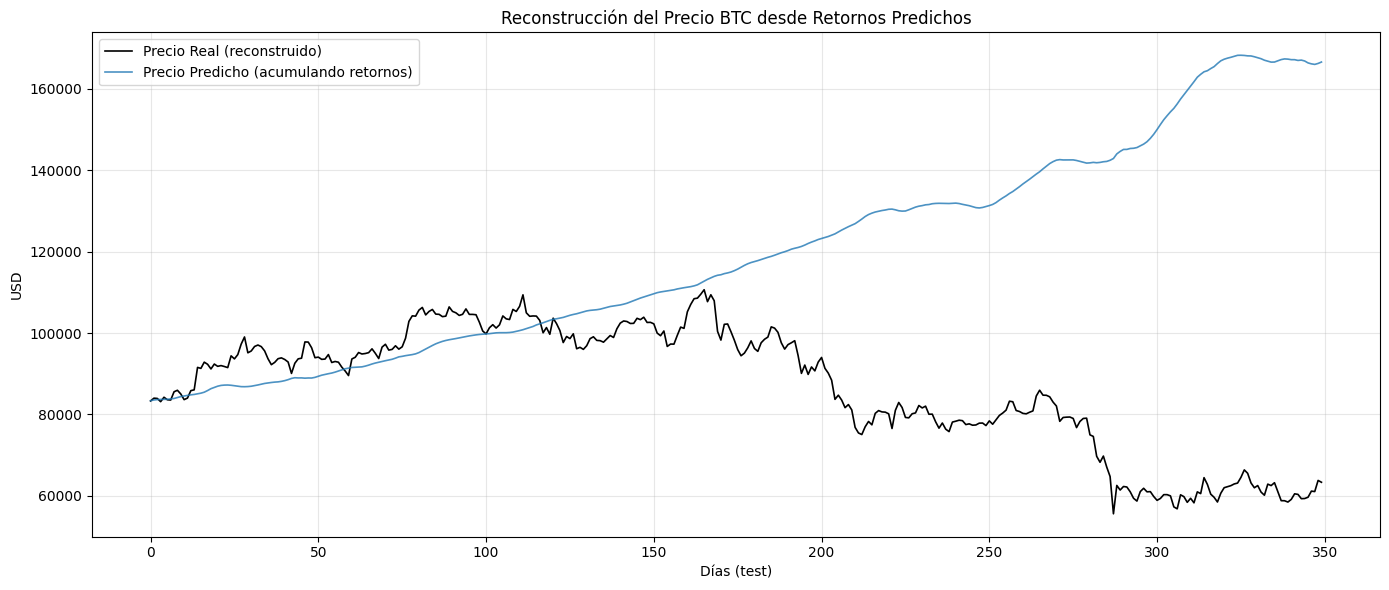

MAPE en precio reconstruido: 50.92%


In [45]:
# ── 15.1 Reconstrucción ───────────────────────────────────────
# Obtener precio real del inicio del período test
test_start_idx = idx_val_end + LB_BEST - 1  # último día antes de la primera predicción
price_at_test_start = float(close["Close"].iloc[test_start_idx])  # float() evita problemas con Series/MultiIndex

print(f"Precio ancla (P₀): ${price_at_test_start:,.2f}")
print(f"Predicciones test: {len(y_real_best)}")

# Acumular retornos logarítmicos
cum_real = np.cumsum(y_real_best.flatten())
cum_pred = np.cumsum(pred_best.flatten())

price_real = price_at_test_start * np.exp(cum_real)
price_pred = price_at_test_start * np.exp(cum_pred)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(price_real, color="black", lw=1.2, label="Precio Real (reconstruido)")
ax.plot(price_pred, lw=1.2, label="Precio Predicho (acumulando retornos)", alpha=0.8)
ax.set_title("Reconstrucción del Precio BTC desde Retornos Predichos")
ax.set_xlabel("Días (test)"); ax.set_ylabel("USD")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Error relativo
mape = np.mean(np.abs((price_real - price_pred) / price_real)) * 100
print(f"MAPE en precio reconstruido: {mape:.2f}%")

---
<a id="16"></a>
# 16. Conclusiones

### Hallazgos principales:

1. **Predecir retornos de criptomonedas es intrínsecamente difícil.** Los retornos logarítmicos se comportan aproximadamente como ruido blanco con colas pesadas. Esto impone un techo de predictibilidad bajo.

2. **El baseline naïve es un adversario fuerte.** Para series financieras de alta frecuencia, la predicción "mañana = hoy" minimiza el MSE porque la mejor estimación de una caminata aleatoria es el último valor observado.

3. **El feature engineering mejora marginalmente las predicciones.** La volatilidad realizada y los retornos rezagados aportan señal adicional, especialmente para la *Directional Accuracy*.

4. **La pérdida Huber es más apropiada que MSE/MAE** para retornos financieros, ya que es cuadrática cerca del cero (sensible a errores pequeños) pero lineal en los extremos (robusta a outliers).

5. **El tuning sistemático es esencial.** Las configuraciones "a mano" del cuaderno original (pruebas 1-5) no exploraron el espacio de hiperparámetros de forma eficiente. La búsqueda grid reveló que combinaciones no intuitivas pueden rendir mejor.

6. **La Directional Accuracy (DA)** es la métrica más relevante para trading: un modelo con DA > 55% en retornos diarios puede ser rentable con una estrategia adecuada.

### Posibles extensiones (trabajo futuro):
- Incorporar features exógenos: volumen, sentiment de redes sociales, datos on-chain.
- Modelos de atención (Transformer) para capturar dependencias de muy largo plazo.
- Ensemble de modelos (stacking) con predictor de volatilidad separado.
- Evaluación con *walk-forward validation* para simular condiciones reales de trading.

---
<a id="17"></a>
# 17. Guardar Modelo y Artefactos

In [46]:
# ── 17.1 Guardar mejor modelo ──────────────────────────────────
from pathlib import Path
import pickle

model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

# Modelo Keras
model_best.save(model_dir / "btc_bilstm_tuned.keras")
print(f"✅ Modelo guardado en: {(model_dir / 'btc_bilstm_tuned.keras').resolve()}")

# Scaler
with open(model_dir / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print(f"✅ Scaler guardado en: {(model_dir / 'scaler.pkl').resolve()}")

# Config
import json
with open(model_dir / "best_config.json", "w") as f:
    json.dump(best_config, f, indent=2)
print(f"✅ Config guardada en: {(model_dir / 'best_config.json').resolve()}")

# Resultados
df_results.to_csv(model_dir / "results_comparison.csv", index=False)
print(f"✅ Resultados guardados en: {(model_dir / 'results_comparison.csv').resolve()}")

✅ Modelo guardado en: C:\Users\Acer\OneDrive\Escritorio\MINE009_Externado\Topicos de mineria de datos ML y Redes Neuronales\Entrega final\RNN\models\btc_bilstm_tuned.keras
✅ Scaler guardado en: C:\Users\Acer\OneDrive\Escritorio\MINE009_Externado\Topicos de mineria de datos ML y Redes Neuronales\Entrega final\RNN\models\scaler.pkl
✅ Config guardada en: C:\Users\Acer\OneDrive\Escritorio\MINE009_Externado\Topicos de mineria de datos ML y Redes Neuronales\Entrega final\RNN\models\best_config.json
✅ Resultados guardados en: C:\Users\Acer\OneDrive\Escritorio\MINE009_Externado\Topicos de mineria de datos ML y Redes Neuronales\Entrega final\RNN\models\results_comparison.csv
